# Tesla Deliveries Dataset (2015–2025)
## Complete Machine Learning & Time Series Notebook

**Dataset:** 2,640 rows × 12 columns  
**Coverage:** 4 Regions · 5 Models · 2015–2025  
**Topics Covered:** Data Cleaning → EDA → Encoding → Scaling → Feature Engineering → Pipelines → Data Leakage → Linear / Ridge / Lasso Regression → Evaluation Metrics → Cross-Validation → Hyperparameter Tuning → Time Series (Components, Stationarity, Lag Features, Rolling Statistics, Forecasting, Chronological Split)


## 0. Imports & Setup

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, GridSearchCV, TimeSeriesSplit)
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder, StandardScaler,
                                   MinMaxScaler, RobustScaler, PolynomialFeatures)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance

# Stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})
SEED = 42
print("✅ All libraries imported successfully")


✅ All libraries imported successfully


---
## 1. Data Cleaning

**Goal:** Load raw data, assess quality, fix issues so downstream analysis is reliable.


In [62]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)


Shape: (2640, 12)

Dtypes:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [63]:
# ── Missing Values ──────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing: 0


In [64]:
# ── Duplicate Rows ──────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# ── Data types & basic stats ──────────────────
print("\nBasic statistics:")
df.describe(include='all')


Duplicate rows: 0

Basic statistics:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


In [65]:
# ── Create a proper Date column ──────────────────
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df = df.sort_values('Date').reset_index(drop=True)

# ── Add derived flag for data quality ────────────
df['Is_Official'] = df['Source_Type'] == 'Official (Quarter)'

# ── Overview ─────────────────────────────────────
print("Cleaned dataset preview:")
df.head(5)


Cleaned dataset preview:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Is_Official
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,True
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,False
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,False
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,False
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,True


---
## 2. Exploratory Data Analysis (EDA)

Understand distributions, trends, relationships, and outliers before modelling.


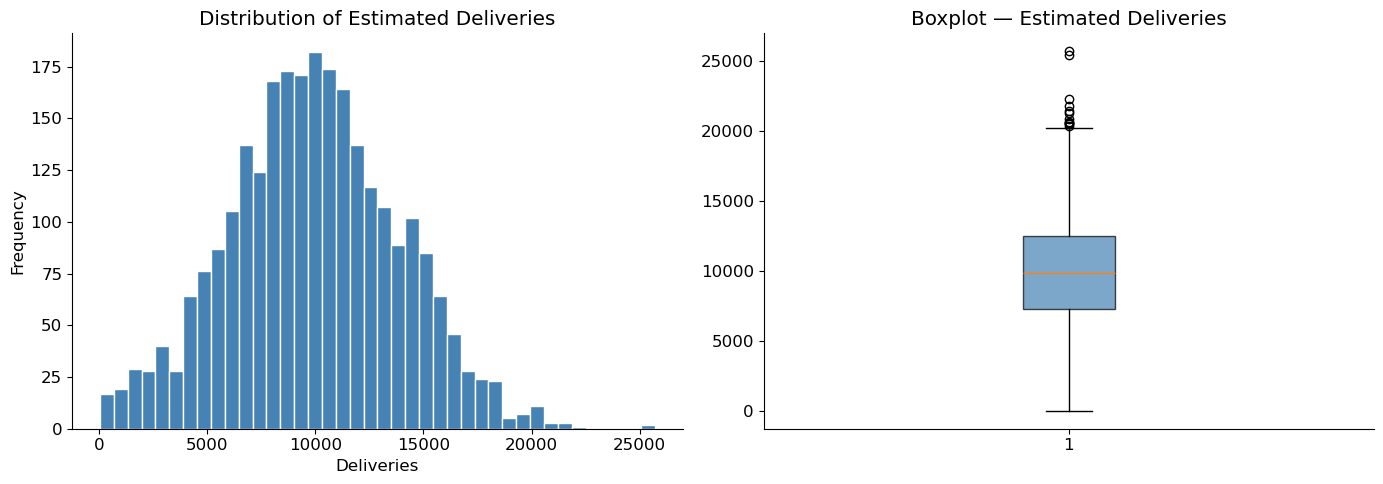

Skewness: 0.088


In [66]:
# ── Univariate: Estimated_Deliveries distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Estimated Deliveries')
axes[0].set_xlabel('Deliveries')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Estimated_Deliveries'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot — Estimated Deliveries')

plt.tight_layout()
plt.show()
print(f"Skewness: {df['Estimated_Deliveries'].skew():.3f}")


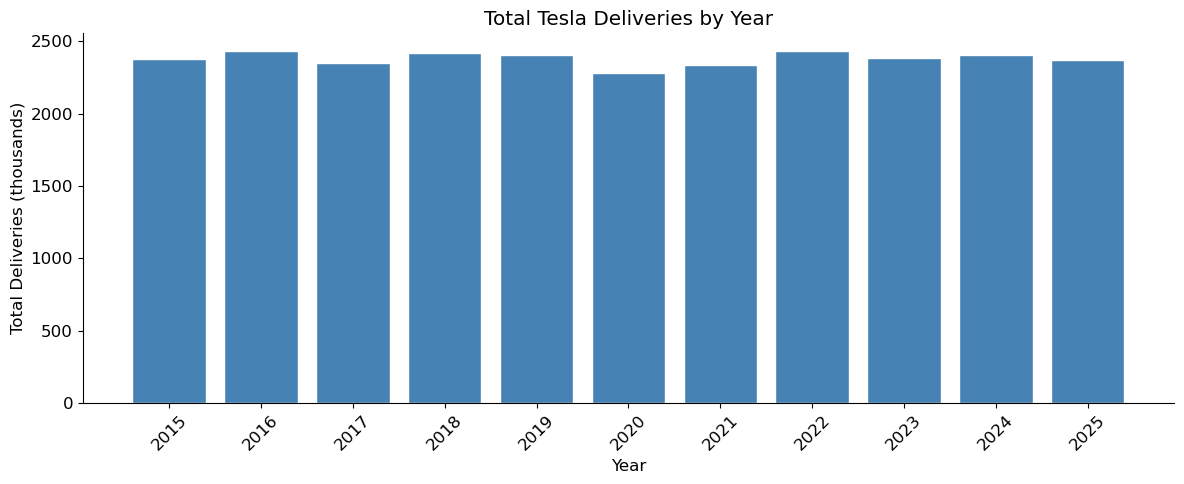

In [67]:
# ── Yearly Deliveries Trend ─────────────────────────
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.bar(yearly['Year'], yearly['Estimated_Deliveries'] / 1_000,
        color='steelblue', edgecolor='white')
plt.xlabel('Year')
plt.ylabel('Total Deliveries (thousands)')
plt.title('Total Tesla Deliveries by Year')
plt.xticks(yearly['Year'], rotation=45)
plt.tight_layout()
plt.show()


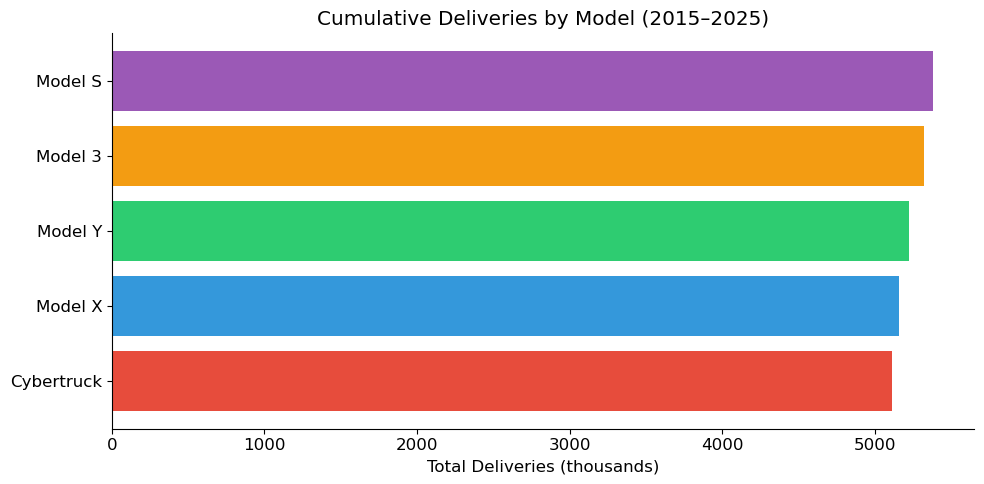

In [68]:
# ── Deliveries by Model ──────────────────────────────
model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()

plt.figure(figsize=(10, 5))
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
plt.barh(model_del.index, model_del.values / 1_000, color=colors)
plt.xlabel('Total Deliveries (thousands)')
plt.title('Cumulative Deliveries by Model (2015–2025)')
plt.tight_layout()
plt.show()


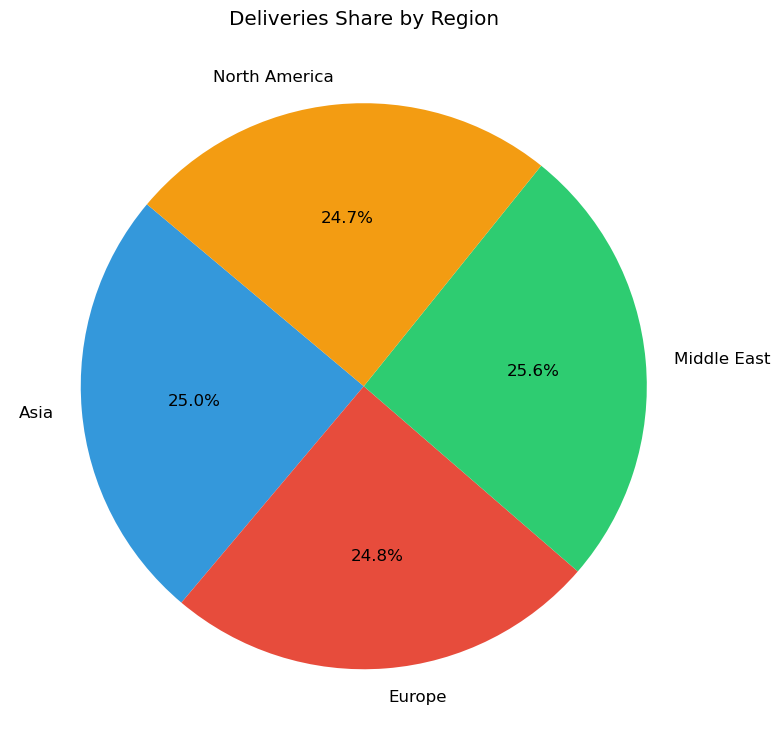

In [69]:
# ── Deliveries by Region ─────────────────────────────
region_del = df.groupby('Region')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8, 8))
plt.pie(region_del, labels=region_del.index, autopct='%1.1f%%',
        startangle=140, colors=['#3498DB','#E74C3C','#2ECC71','#F39C12'])
plt.title('Deliveries Share by Region')
plt.tight_layout()
plt.show()


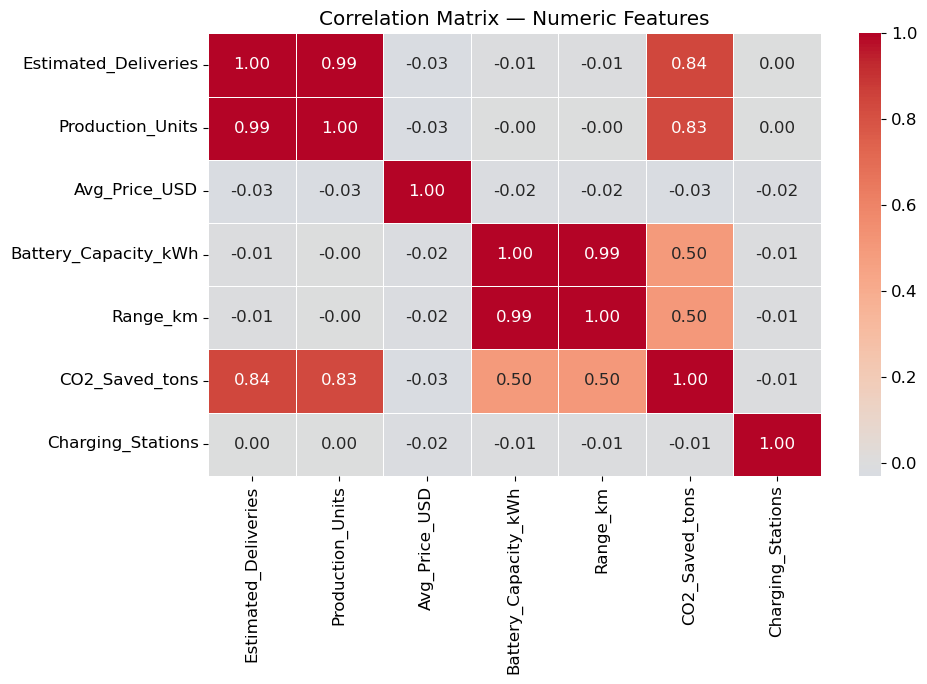

In [70]:
# ── Heatmap: Correlation matrix ─────────────────────
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()


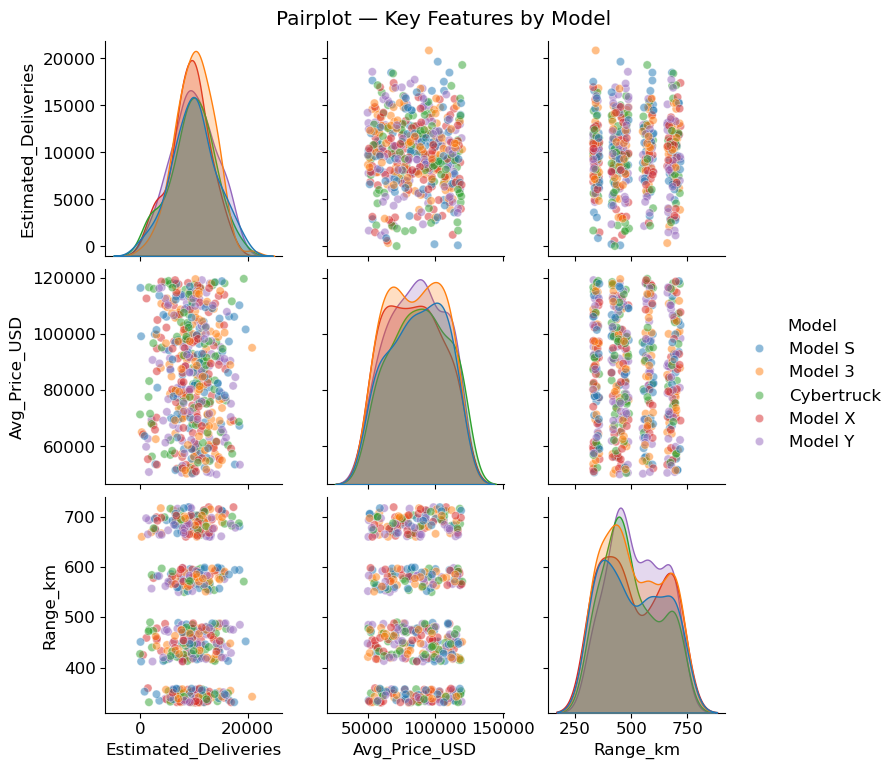

In [71]:
# ── Pairplot: Key relationships ──────────────────────
sample = df[['Estimated_Deliveries', 'Avg_Price_USD', 'Range_km', 'Model']].sample(500, random_state=SEED)
sns.pairplot(sample, hue='Model', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot — Key Features by Model', y=1.02)
plt.show()


---
## 3. Encoding Techniques

Convert categorical variables (Region, Model, Source_Type) into numeric form.

| Technique | When to use |
|-----------|-------------|
| **Label Encoding** | Ordinal categories / tree models |
| **One-Hot Encoding** | Nominal categories / linear models |
| **Binary / Target Encoding** | High-cardinality (not needed here) |


In [72]:
df_enc = df.copy()

# ── Label Encoding ────────────────────────────────
le_region = LabelEncoder()
le_model  = LabelEncoder()

df_enc['Region_LabelEnc'] = le_region.fit_transform(df_enc['Region'])
df_enc['Model_LabelEnc']  = le_model.fit_transform(df_enc['Model'])

print("Label Encoded — Region mapping:")
for cls, idx in zip(le_region.classes_, le_region.transform(le_region.classes_)):
    print(f"  {cls:15s} → {idx}")


Label Encoded — Region mapping:
  Asia            → 0
  Europe          → 1
  Middle East     → 2
  North America   → 3


In [73]:
# ── One-Hot Encoding ─────────────────────────────────
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe_cols = ohe.fit_transform(df_enc[['Region', 'Model']])
ohe_names = ohe.get_feature_names_out(['Region', 'Model'])

df_ohe = pd.DataFrame(ohe_cols, columns=ohe_names, index=df_enc.index)
df_enc = pd.concat([df_enc, df_ohe], axis=1)

print(f"One-Hot columns added: {list(ohe_names)}")
print(f"\nDataset now has {df_enc.shape[1]} columns")
df_enc[['Region', 'Region_LabelEnc'] + list(ohe_names[:4])].head(5)


One-Hot columns added: ['Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y']

Dataset now has 23 columns


,Region,Region_LabelEnc,Region_Europe,Region_Middle East,Region_North America,Model_Model 3
0,Asia,0,0.0,0.0,0.0,0.0
1,Middle East,2,0.0,1.0,0.0,1.0
2,Middle East,2,0.0,1.0,0.0,0.0
3,North America,3,0.0,0.0,1.0,0.0
4,Asia,0,0.0,0.0,0.0,1.0


---
## 4. Feature Scaling

Linear models and distance-based algorithms require features on comparable scales.

| Scaler | Formula | Best for |
|--------|---------|----------|
| **StandardScaler** | (x - μ) / σ | Normally distributed features |
| **MinMaxScaler** | (x - min) / (max - min) | Bounded ranges needed |
| **RobustScaler** | (x - median) / IQR | Outlier-heavy features |


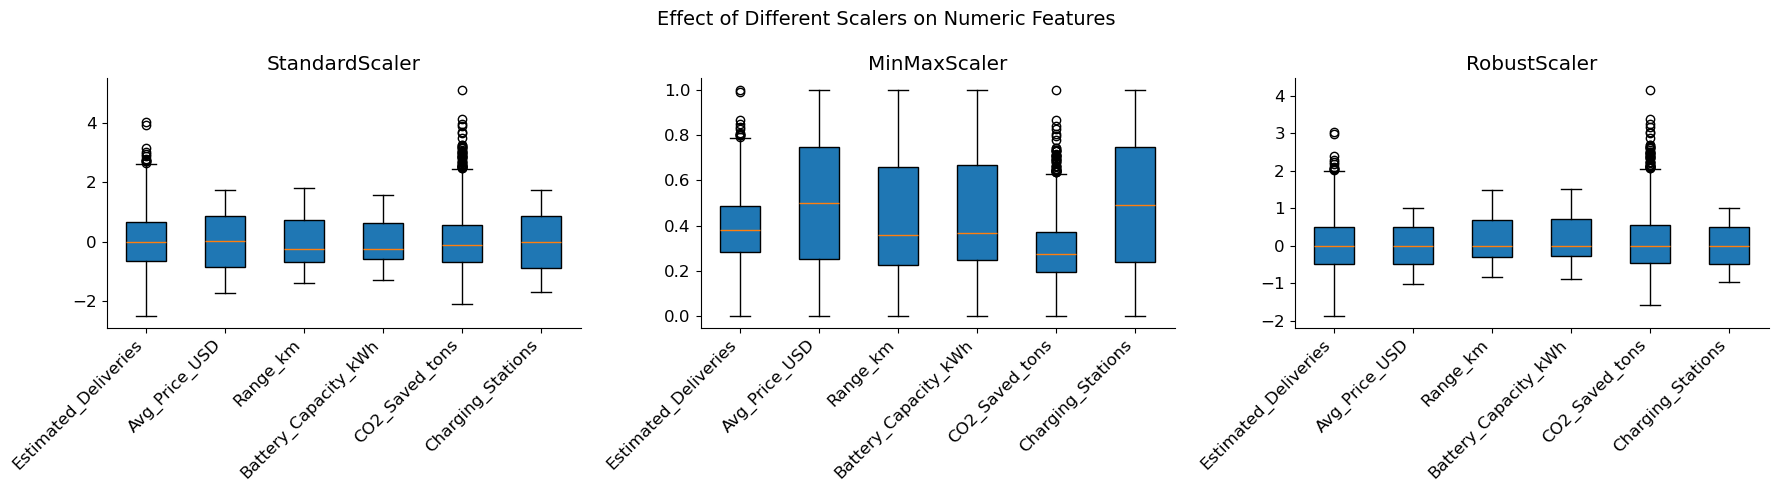

In [74]:
scale_features = ['Estimated_Deliveries', 'Avg_Price_USD', 'Range_km',
                  'Battery_Capacity_kWh', 'CO2_Saved_tons', 'Charging_Stations']

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, scaler) in zip(axes, scalers.items()):
    scaled = scaler.fit_transform(df[scale_features])
    ax.boxplot(scaled, labels=scale_features, vert=True, patch_artist=True)
    ax.set_title(name)
    ax.set_xticklabels(scale_features, rotation=45, ha='right')

plt.suptitle('Effect of Different Scalers on Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()


---
## 5. Feature Engineering

Create new informative features from existing ones to improve model signal.


In [75]:
df_fe = df_enc.copy()

# ── 1. Production efficiency ratio ───────────────
df_fe['Production_Efficiency'] = (
    df_fe['Estimated_Deliveries'] / df_fe['Production_Units'].replace(0, np.nan)
).fillna(0)

# ── 2. Revenue proxy ────────────────────────────────
df_fe['Revenue_Proxy'] = df_fe['Estimated_Deliveries'] * df_fe['Avg_Price_USD']

# ── 3. Charging density (stations per delivery) ─────
df_fe['Charging_per_Delivery'] = (
    df_fe['Charging_Stations'] / df_fe['Estimated_Deliveries'].replace(0, np.nan)
).fillna(0)

# ── 4. Season ────────────────────────────────────────
df_fe['Season'] = pd.cut(df_fe['Month'], bins=[0,3,6,9,12],
                          labels=['Q1','Q2','Q3','Q4'])

# ── 5. Polynomial features (for price & range) ──────
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr = poly.fit_transform(df_fe[['Avg_Price_USD', 'Range_km']])
poly_names = poly.get_feature_names_out(['Avg_Price_USD', 'Range_km'])
df_poly = pd.DataFrame(poly_arr, columns=poly_names, index=df_fe.index)
df_fe = pd.concat([df_fe, df_poly[['Avg_Price_USD^2', 'Range_km^2',
                                    'Avg_Price_USD Range_km']]], axis=1)

print("New engineered features:", ['Production_Efficiency', 'Revenue_Proxy',
      'Charging_per_Delivery', 'Season', 'Avg_Price_USD^2', 'Range_km^2',
      'Avg_Price_USD Range_km'])
df_fe[['Production_Efficiency', 'Revenue_Proxy', 'Charging_per_Delivery']].describe()


New engineered features: ['Production_Efficiency', 'Revenue_Proxy', 'Charging_per_Delivery', 'Season', 'Avg_Price_USD^2', 'Range_km^2', 'Avg_Price_USD Range_km']


,Production_Efficiency,Revenue_Proxy,Charging_per_Delivery
count,2640.000000,2.640000e+03,2640.000000
mean,0.932619,8.402867e+08,1.476181
std,0.037232,3.937252e+08,6.145977
min,0.869683,3.427300e+06,0.162416
25%,0.899904,5.672172e+08,0.597302
50%,0.932176,8.040993e+08,0.899498
75%,0.964178,1.073729e+09,1.347599
max,1.000000,2.417428e+09,230.625000


---
## 6. Pipelines

Pipelines chain preprocessing and modelling into a single, reproducible object — preventing leakage and simplifying cross-validation.


In [76]:
# ── Feature sets ─────────────────────────────────────
num_features = ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                'CO2_Saved_tons', 'Charging_Stations', 'Month', 'Year']
cat_features = ['Region', 'Model']
target       = 'Estimated_Deliveries'

X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

# ── Preprocessor ──────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features),
])

# ── Full Pipeline ──────────────────────────────────────
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression()),
])

pipeline_lr.fit(X_train, y_train)
y_pred_pipe = pipeline_lr.predict(X_test)

print("Pipeline R²  :", round(r2_score(y_test, y_pred_pipe), 4))
print("Pipeline MAE :", round(mean_absolute_error(y_test, y_pred_pipe), 2))
print("\nPipeline steps:")
for step in pipeline_lr.steps:
    print(f"  {step[0]:15s} → {step[1].__class__.__name__}")


Pipeline R²  : 0.9414
Pipeline MAE : 672.63

Pipeline steps:
  preprocessor    → ColumnTransformer
  model           → LinearRegression


---
## 7. Data Leakage

Data leakage occurs when information from **outside** the training set contaminates the model — producing overly optimistic metrics that collapse in production.

### Common Leakage Types

| Type | Example in this dataset |
|------|------------------------|
| **Target leakage** | Using `Production_Units` (set after deliveries are known) as a direct feature |
| **Temporal leakage** | Fitting scaler on full data before chronological split |
| **Train-test contamination** | Calling `.fit_transform()` on X before splitting |


In [77]:
# ── Demo: leakage vs no-leakage ─────────────────────────
# BAD: scale before split (leaks test statistics into training)
scaler_bad = StandardScaler()
X_num = df[num_features]
X_scaled_bad = scaler_bad.fit_transform(X_num)   # ← fits on ALL data

X_tr_bad, X_te_bad, y_tr, y_te = train_test_split(
    X_scaled_bad, y, test_size=0.2, random_state=SEED)

lr_bad = LinearRegression().fit(X_tr_bad, y_tr)
r2_bad = r2_score(y_te, lr_bad.predict(X_te_bad))

# GOOD: scale INSIDE pipeline (fits only on training data per fold)
scaler_good = StandardScaler()
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_num, y, test_size=0.2, random_state=SEED)

X_tr_good = scaler_good.fit_transform(X_tr_raw)   # ← fits on train only
X_te_good = scaler_good.transform(X_te_raw)        # ← applies same transform

lr_good = LinearRegression().fit(X_tr_good, y_tr)
r2_good = r2_score(y_te, lr_good.predict(X_te_good))

print(f"R² with leakage  (BAD) : {r2_bad:.4f}")
print(f"R² without leakage (GOOD): {r2_good:.4f}")
print("\n✅ Use sklearn Pipelines to prevent leakage automatically.")


R² with leakage  (BAD) : 0.9416
R² without leakage (GOOD): 0.9416

✅ Use sklearn Pipelines to prevent leakage automatically.


---
## 8. Linear Regression

Ordinary Least Squares (OLS): minimises sum of squared residuals.  
**Assumption:** Linear relationship between features and target.


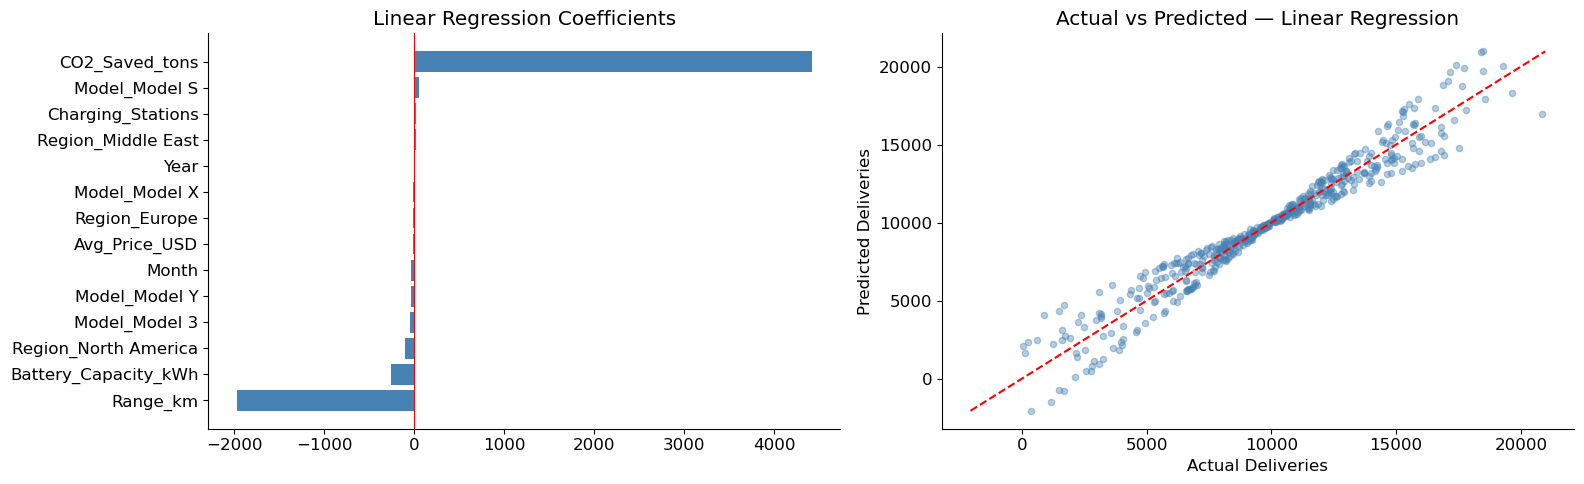

In [78]:
# Use pipeline preprocessor output
X_train_proc = pipeline_lr.named_steps['preprocessor'].transform(X_train)
X_test_proc  = pipeline_lr.named_steps['preprocessor'].transform(X_test)

lr = LinearRegression()
lr.fit(X_train_proc, y_train)
y_pred_lr = lr.predict(X_test_proc)

# ── Coefficients ────────────────────────────────────────
feature_names = (num_features +
    list(pipeline_lr.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(cat_features)))

coef_df = pd.DataFrame({'Feature': feature_names,
                         'Coefficient': lr.coef_}).sort_values('Coefficient')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Coefficients plot
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
axes[0].axvline(0, color='red', linewidth=0.8)
axes[0].set_title('Linear Regression Coefficients')

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', s=20)
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set_xlabel('Actual Deliveries')
axes[1].set_ylabel('Predicted Deliveries')
axes[1].set_title('Actual vs Predicted — Linear Regression')

plt.tight_layout()
plt.show()


---
## 9. Ridge Regression (L2)

Adds an L2 penalty: minimises **RSS + α·Σβ²**  
- Shrinks coefficients toward zero; **never sets them to exactly zero**  
- Controls multicollinearity  
- Hyperparameter **α** controls regularisation strength


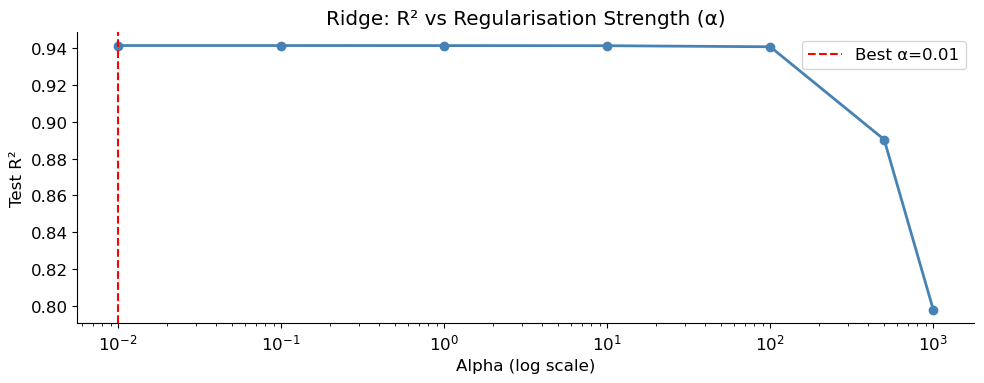

Best α: 0.01  →  R²: 0.9414


In [79]:
alphas = [0.01, 0.1, 1, 10, 100, 500, 1000]
ridge_r2 = []

for a in alphas:
    pipe_r = Pipeline([('pre', preprocessor), ('model', Ridge(alpha=a))])
    pipe_r.fit(X_train, y_train)
    ridge_r2.append(r2_score(y_test, pipe_r.predict(X_test)))

plt.figure(figsize=(10, 4))
plt.semilogx(alphas, ridge_r2, 'o-', color='steelblue', lw=2)
plt.xlabel('Alpha (log scale)')
plt.ylabel('Test R²')
plt.title('Ridge: R² vs Regularisation Strength (α)')
plt.axvline(alphas[np.argmax(ridge_r2)], color='red', ls='--',
            label=f'Best α={alphas[np.argmax(ridge_r2)]}')
plt.legend()
plt.tight_layout()
plt.show()

best_alpha_ridge = alphas[np.argmax(ridge_r2)]
pipe_ridge = Pipeline([('pre', preprocessor), ('model', Ridge(alpha=best_alpha_ridge))])
pipe_ridge.fit(X_train, y_train)
y_pred_ridge = pipe_ridge.predict(X_test)
print(f"Best α: {best_alpha_ridge}  →  R²: {max(ridge_r2):.4f}")


---
## 10. Lasso Regression (L1)

Adds an L1 penalty: minimises **RSS + α·Σ|β|**  
- Performs **automatic feature selection** (drives some coefficients to exactly zero)  
- Better when many features are irrelevant


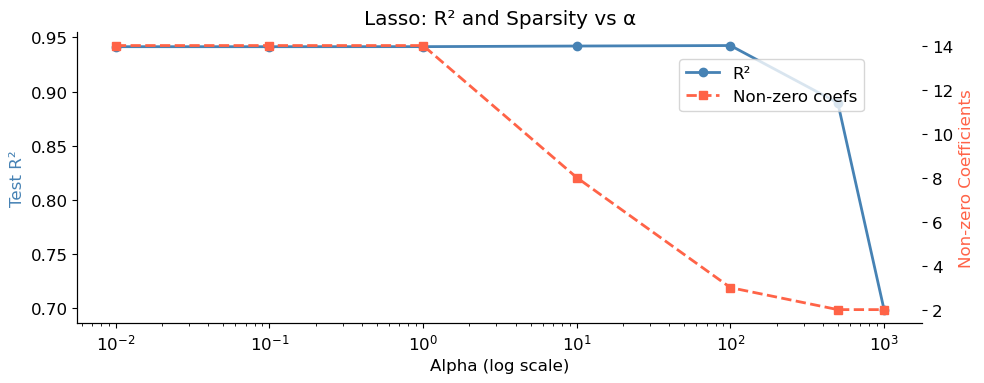

Best α: 100  →  R²: 0.9424
Non-zero coefficients at best α: 3


In [80]:
lasso_r2 = []
lasso_nnz = []   # non-zero coefficients

for a in alphas:
    pipe_l = Pipeline([('pre', preprocessor), ('model', Lasso(alpha=a, max_iter=5000))])
    pipe_l.fit(X_train, y_train)
    y_pred_l = pipe_l.predict(X_test)
    lasso_r2.append(r2_score(y_test, y_pred_l))
    lasso_nnz.append((pipe_l.named_steps['model'].coef_ != 0).sum())

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.semilogx(alphas, lasso_r2, 'o-', color='steelblue', lw=2, label='R²')
ax2.semilogx(alphas, lasso_nnz, 's--', color='tomato', lw=2, label='Non-zero coefs')
ax1.set_xlabel('Alpha (log scale)')
ax1.set_ylabel('Test R²', color='steelblue')
ax2.set_ylabel('Non-zero Coefficients', color='tomato')
ax1.set_title('Lasso: R² and Sparsity vs α')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.85))
plt.tight_layout()
plt.show()

best_alpha_lasso = alphas[np.argmax(lasso_r2)]
print(f"Best α: {best_alpha_lasso}  →  R²: {max(lasso_r2):.4f}")
print(f"Non-zero coefficients at best α: {lasso_nnz[np.argmax(lasso_r2)]}")


---
## 11. Evaluation Metrics

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **MAE** | mean(|y - ŷ|) | Average absolute error (same unit as target) |
| **MSE** | mean((y - ŷ)²) | Penalises large errors heavily |
| **RMSE** | √MSE | Same unit as target; sensitive to outliers |
| **MAPE** | mean(|(y - ŷ)/y|) × 100 | Percentage error; scale-independent |
| **R²** | 1 - SS_res/SS_tot | Proportion of variance explained (1 = perfect) |


                      MAE        MSE    RMSE  MAPE (%)    R²
Model                                                       
Linear Regression  672.63  878373.74  937.22     24.78  0.94
Ridge (best α)     672.63  878378.43  937.22     24.78  0.94
Pipeline LR        672.63  878373.74  937.22     24.78  0.94


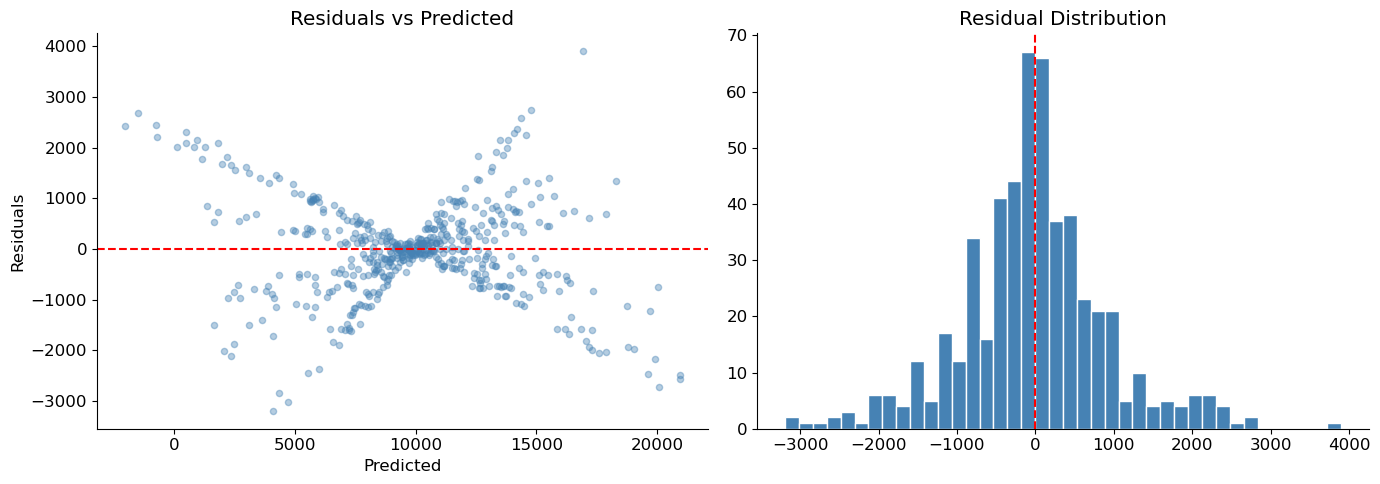

In [81]:
models = {
    'Linear Regression': y_pred_lr,
    'Ridge (best α)':    y_pred_ridge,
    'Pipeline LR':       y_pred_pipe,
}

metrics_data = []
for name, pred in models.items():
    mae  = mean_absolute_error(y_test, pred)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    r2   = r2_score(y_test, pred)
    metrics_data.append({'Model': name, 'MAE': mae, 'MSE': mse,
                          'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2})

metrics_df = pd.DataFrame(metrics_data).set_index('Model')
print(metrics_df.round(2))

# ── Residuals plot ────────────────────────────────────
residuals = y_test - y_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_lr, residuals, alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()


---
## 12. Cross-Validation

K-Fold CV gives a more reliable estimate of generalisation performance by training and evaluating on **K different splits**.


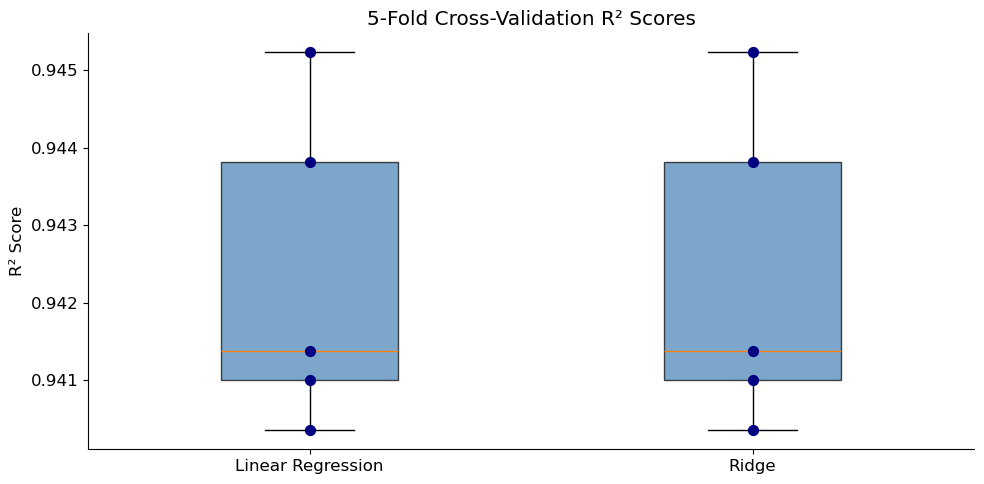

Linear Regression  — Mean R²: 0.9424 ± 0.0019
Ridge Regression   — Mean R²: 0.9424 ± 0.0019


In [82]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores_lr    = cross_val_score(pipeline_lr,  X, y, cv=kf, scoring='r2')
cv_scores_ridge = cross_val_score(Pipeline([('pre', preprocessor),
                                             ('model', Ridge(alpha=best_alpha_ridge))]),
                                   X, y, cv=kf, scoring='r2')

fig, ax = plt.subplots(figsize=(10, 5))
positions = [1, 2]
bp = ax.boxplot([cv_scores_lr, cv_scores_ridge], positions=positions,
                patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='steelblue', alpha=0.7))

ax.scatter([1]*5, cv_scores_lr, color='navy', zorder=5, s=50)
ax.scatter([2]*5, cv_scores_ridge, color='navy', zorder=5, s=50)
ax.set_xticks(positions)
ax.set_xticklabels(['Linear Regression', 'Ridge'])
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation R² Scores')
plt.tight_layout()
plt.show()

print(f"Linear Regression  — Mean R²: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"Ridge Regression   — Mean R²: {cv_scores_ridge.mean():.4f} ± {cv_scores_ridge.std():.4f}")


---
## 13. Hyperparameter Tuning

**GridSearchCV** exhaustively searches a parameter grid using cross-validation.


Best parameters: {'model__alpha': 1}
Best CV R²: 0.9425
Test R²   : 0.9413


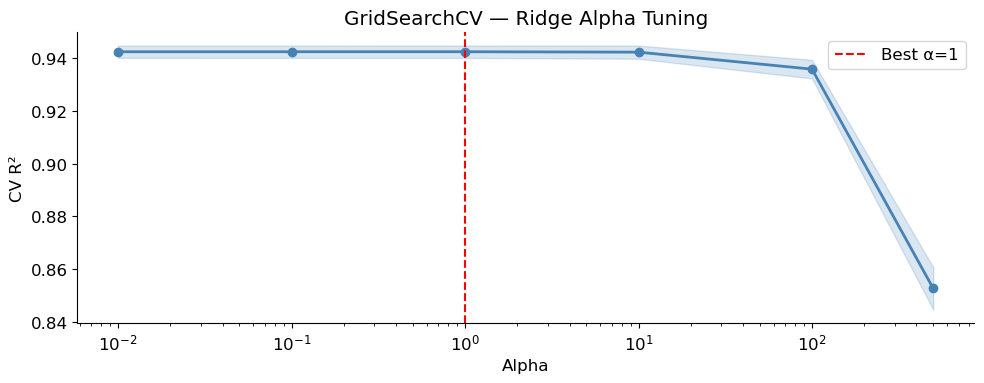

In [83]:
param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100, 500],
}

ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge()),
])

grid_search = GridSearchCV(
    ridge_pipe, param_grid, cv=5,
    scoring='r2', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV R²: {grid_search.best_score_:.4f}")
print(f"Test R²   : {r2_score(y_test, grid_search.predict(X_test)):.4f}")

# ── Visualise the search ──────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 4))
plt.semilogx(param_grid['model__alpha'],
             results['mean_test_score'], 'o-', color='steelblue', lw=2)
plt.fill_between(param_grid['model__alpha'],
                 results['mean_test_score'] - results['std_test_score'],
                 results['mean_test_score'] + results['std_test_score'],
                 alpha=0.2, color='steelblue')
plt.xlabel('Alpha')
plt.ylabel('CV R²')
plt.title('GridSearchCV — Ridge Alpha Tuning')
plt.axvline(grid_search.best_params_['model__alpha'],
            color='red', ls='--', label=f"Best α={grid_search.best_params_['model__alpha']}")
plt.legend()
plt.tight_layout()
plt.show()


---
## 14. Time Series Components

Decompose the global monthly delivery series into:  
**Trend + Seasonality + Residual**


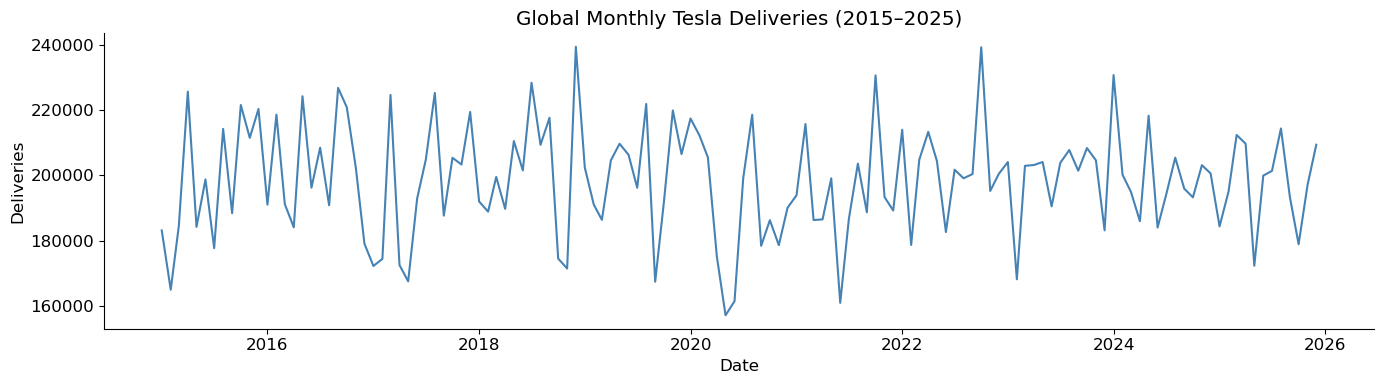

In [84]:
# Aggregate monthly global deliveries
ts = df.groupby('Date')['Estimated_Deliveries'].sum()
ts = ts.asfreq('MS')  # Monthly Start frequency

# ── Plot raw series ───────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(ts.index, ts.values, color='steelblue', lw=1.5)
plt.title('Global Monthly Tesla Deliveries (2015–2025)')
plt.ylabel('Deliveries')
plt.xlabel('Date')
plt.tight_layout()
plt.show()


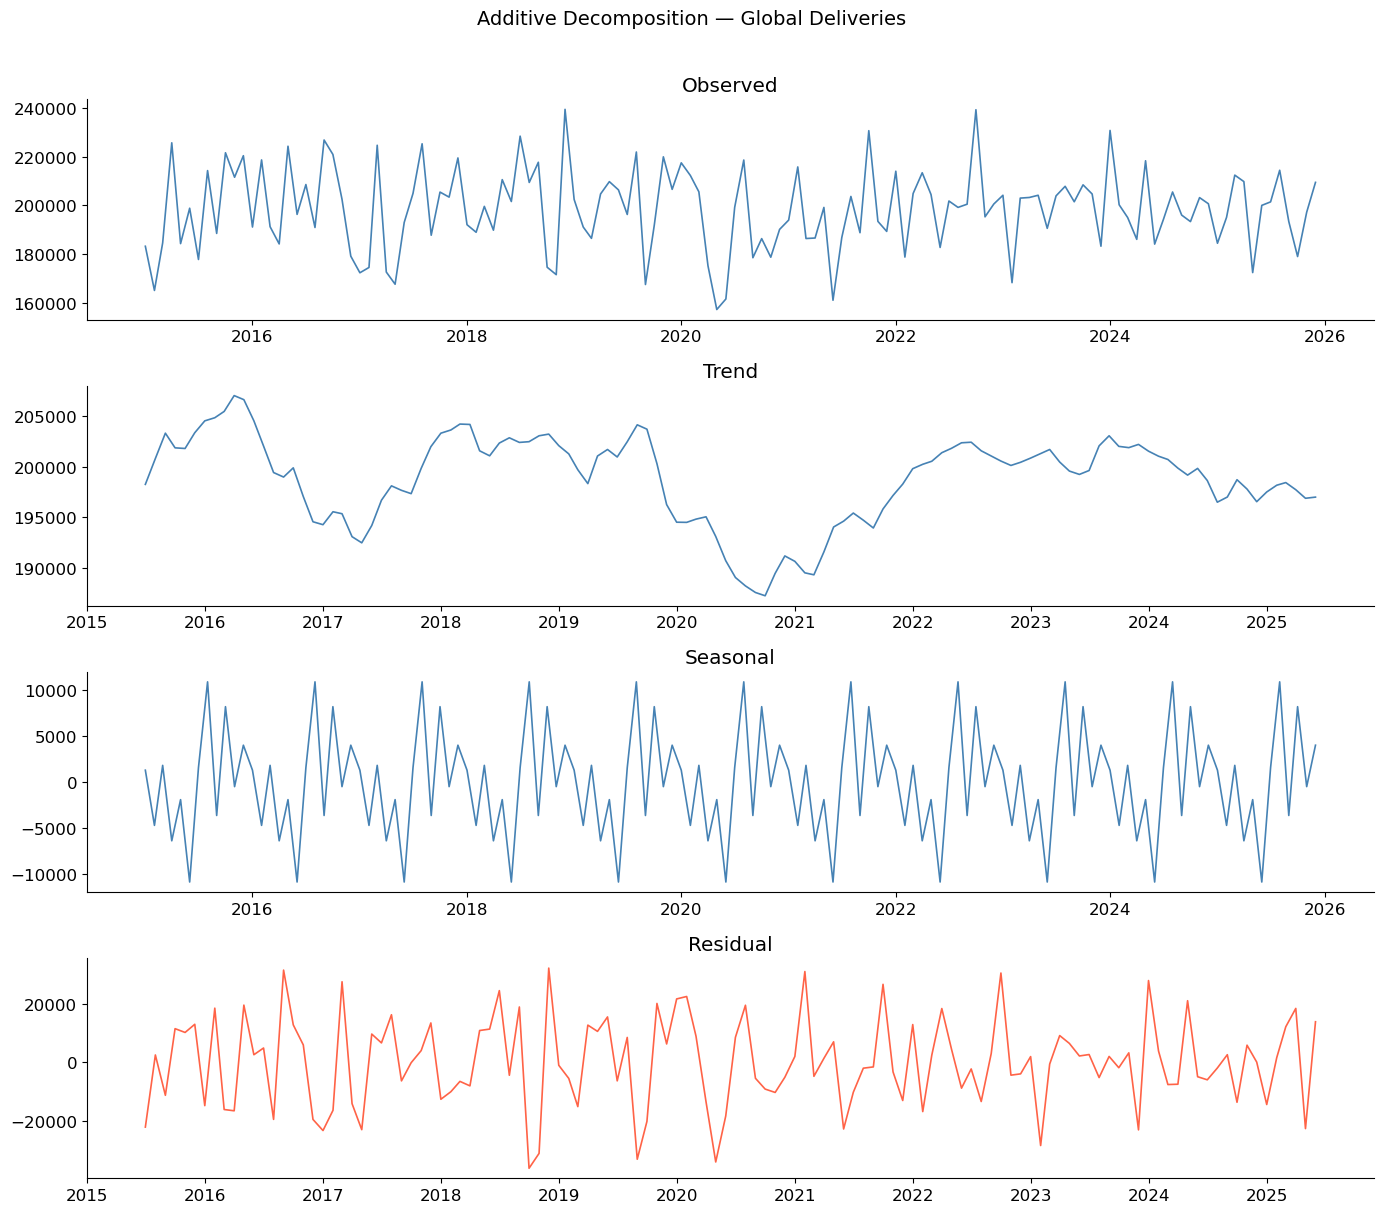

In [85]:
# ── Seasonal Decomposition ────────────────────────────
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
components = [('Observed', decomp.observed),
              ('Trend',    decomp.trend),
              ('Seasonal', decomp.seasonal),
              ('Residual', decomp.resid)]

for ax, (name, data) in zip(axes, components):
    color = 'steelblue' if name != 'Residual' else 'tomato'
    ax.plot(data.index, data.values, color=color, lw=1.2)
    ax.set_title(name)
    ax.set_xlabel('')

plt.suptitle('Additive Decomposition — Global Deliveries', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
## 15. Stationarity

A time series is **stationary** when its statistical properties (mean, variance, autocorrelation) don't change over time.  
Many forecasting models (ARIMA, regression on lags) require stationarity.

**Augmented Dickey-Fuller (ADF) Test**  
- H₀: Series has a unit root (non-stationary)  
- If p-value < 0.05 → reject H₀ → series is stationary


────────────────────────────────────────
ADF Test: Raw Deliveries
  ADF Statistic : -8.8810
  p-value       : 0.0000
  Lags Used     : 1
  Conclusion    : ✅ Stationary
────────────────────────────────────────
ADF Test: First-Differenced Deliveries
  ADF Statistic : -7.0101
  p-value       : 0.0000
  Lags Used     : 7
  Conclusion    : ✅ Stationary


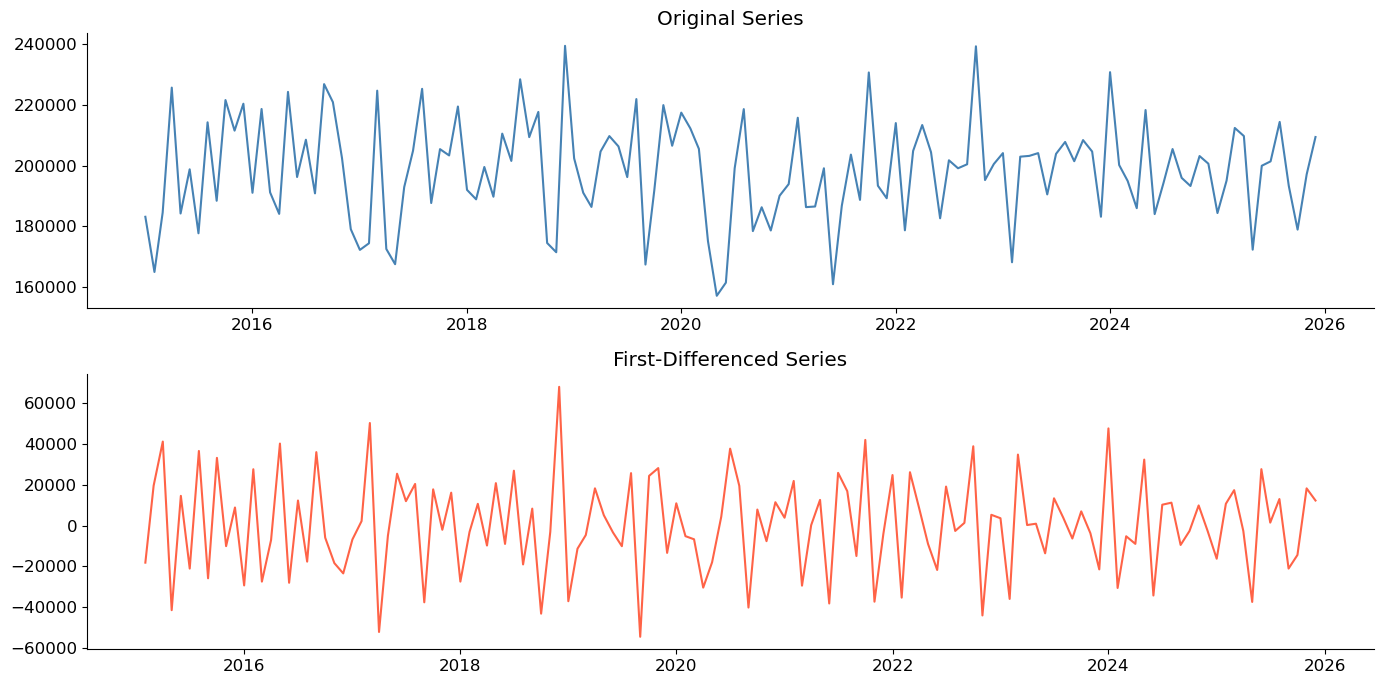

In [86]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"{'─'*40}")
    print(f"ADF Test: {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Lags Used     : {result[2]}")
    conclusion = "✅ Stationary" if result[1] < 0.05 else "❌ Non-Stationary"
    print(f"  Conclusion    : {conclusion}")

adf_test(ts, 'Raw Deliveries')

# First difference to induce stationarity
ts_diff = ts.diff().dropna()
adf_test(ts_diff, 'First-Differenced Deliveries')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(ts.index, ts.values, color='steelblue'); axes[0].set_title('Original Series')
axes[1].plot(ts_diff.index, ts_diff.values, color='tomato'); axes[1].set_title('First-Differenced Series')
plt.tight_layout()
plt.show()


---
## 16. Lag Features

Lag features capture **autocorrelation** — the relationship between a value and its past values.  
Essential for any supervised learning approach to time series.


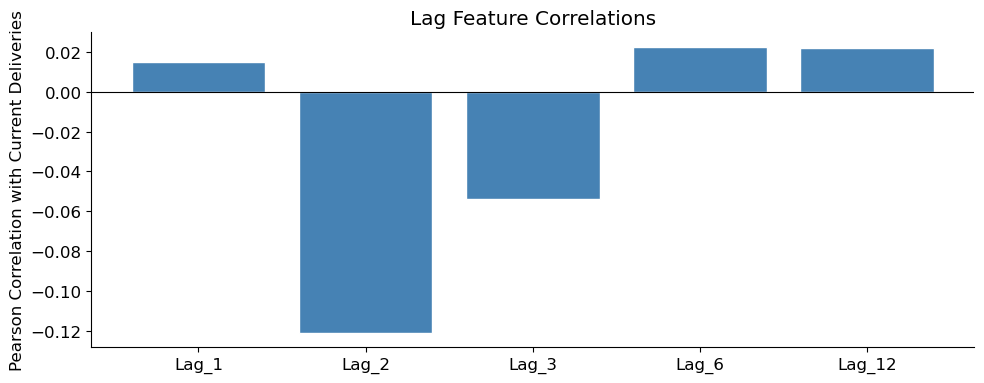

Lag correlations:
Lag_1     0.0148
Lag_2    -0.1210
Lag_3    -0.0538
Lag_6     0.0227
Lag_12    0.0221
Name: Deliveries, dtype: float64


In [87]:
ts_df = ts.reset_index()
ts_df.columns = ['Date', 'Deliveries']

# Create lags 1–6 and 12
for lag in [1, 2, 3, 6, 12]:
    ts_df[f'Lag_{lag}'] = ts_df['Deliveries'].shift(lag)

ts_df = ts_df.dropna()

# ── Correlation of lags with current value ─────────────
lag_cols = [c for c in ts_df.columns if c.startswith('Lag_')]
lag_corr = ts_df[lag_cols + ['Deliveries']].corr()['Deliveries'].drop('Deliveries')

plt.figure(figsize=(10, 4))
plt.bar(lag_corr.index, lag_corr.values, color='steelblue', edgecolor='white')
plt.axhline(0, color='black', lw=0.8)
plt.ylabel('Pearson Correlation with Current Deliveries')
plt.title('Lag Feature Correlations')
plt.tight_layout()
plt.show()

print("Lag correlations:")
print(lag_corr.round(4))


---
## 17. Rolling Statistics

Rolling (sliding window) statistics smooth noise and reveal trends.  
Common in feature engineering for time series and as model inputs.


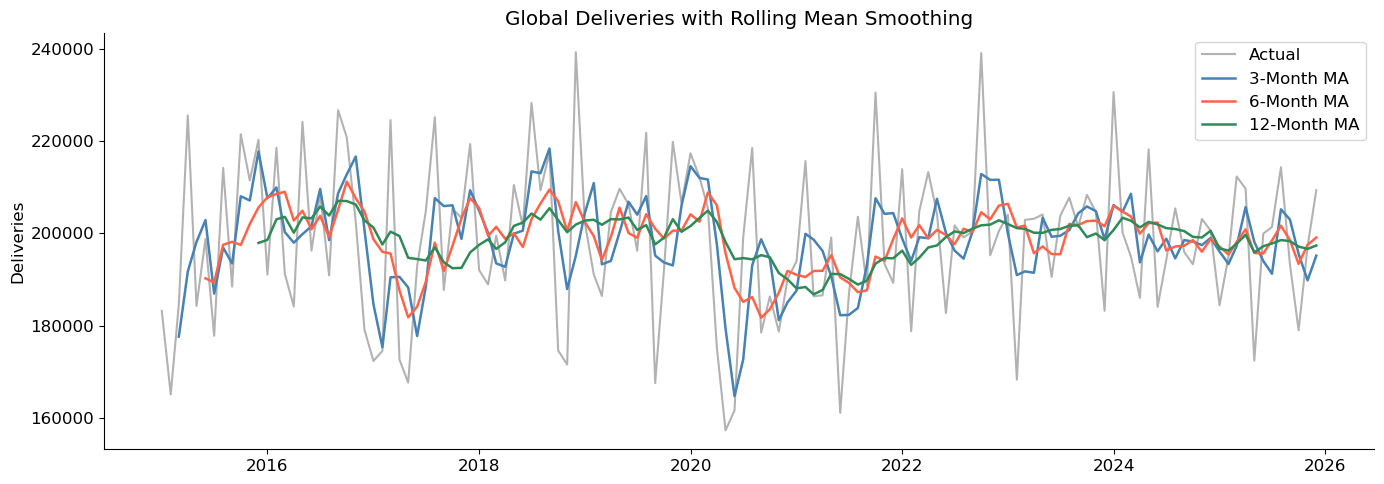

In [88]:
ts_roll = ts.to_frame('Deliveries')

for w in [3, 6, 12]:
    ts_roll[f'RollingMean_{w}m']   = ts_roll['Deliveries'].rolling(w).mean()
    ts_roll[f'RollingStd_{w}m']    = ts_roll['Deliveries'].rolling(w).std()
    ts_roll[f'RollingMax_{w}m']    = ts_roll['Deliveries'].rolling(w).max()

plt.figure(figsize=(14, 5))
plt.plot(ts_roll.index, ts_roll['Deliveries'], label='Actual', color='grey', alpha=0.6)
for w, color in zip([3, 6, 12], ['steelblue', 'tomato', 'seagreen']):
    plt.plot(ts_roll.index, ts_roll[f'RollingMean_{w}m'],
             label=f'{w}-Month MA', color=color, lw=1.8)

plt.legend()
plt.title('Global Deliveries with Rolling Mean Smoothing')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()


---
## 18. Forecasting

Build a supervised regression model on lag and rolling features to forecast future deliveries.


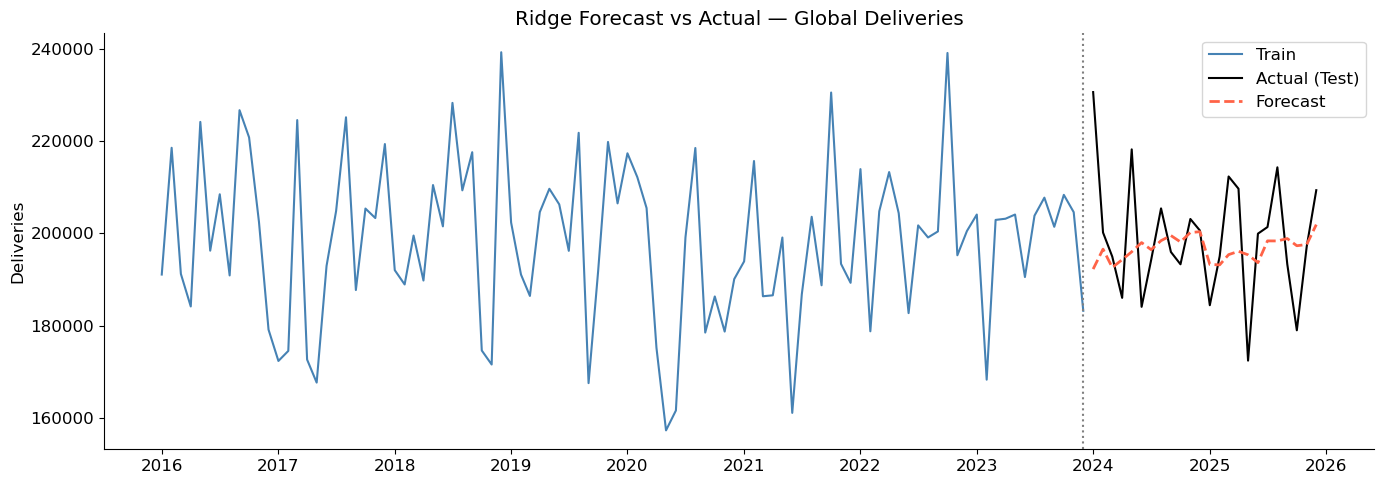

Forecast MAE : 9631
Forecast RMSE: 13172
Forecast R²  : -0.0600


In [89]:
# Feature matrix from lags + rolling stats
ts_feat = ts_roll[['Deliveries']].copy()
for lag in [1, 2, 3, 6, 12]:
    ts_feat[f'Lag_{lag}'] = ts_feat['Deliveries'].shift(lag)

ts_feat['RollMean_3']  = ts_feat['Deliveries'].rolling(3).mean().shift(1)
ts_feat['RollMean_6']  = ts_feat['Deliveries'].rolling(6).mean().shift(1)
ts_feat['Month']       = ts_feat.index.month
ts_feat['Year']        = ts_feat.index.year
ts_feat = ts_feat.dropna()

X_ts = ts_feat.drop(columns='Deliveries')
y_ts = ts_feat['Deliveries']

# Chronological split (80/20)
split = int(len(ts_feat) * 0.8)
X_tr, X_te = X_ts.iloc[:split], X_ts.iloc[split:]
y_tr, y_te = y_ts.iloc[:split], y_ts.iloc[split:]

# Ridge forecaster
scaler_ts = StandardScaler()
X_tr_sc = scaler_ts.fit_transform(X_tr)
X_te_sc  = scaler_ts.transform(X_te)

ridge_ts = Ridge(alpha=10)
ridge_ts.fit(X_tr_sc, y_tr)
y_hat = ridge_ts.predict(X_te_sc)

# ── Plot ────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_tr.index, y_tr.values, label='Train', color='steelblue')
plt.plot(y_te.index, y_te.values, label='Actual (Test)', color='black')
plt.plot(y_te.index, y_hat,        label='Forecast',      color='tomato', lw=2, ls='--')
plt.axvline(y_tr.index[-1], color='grey', ls=':', lw=1.5)
plt.legend()
plt.title('Ridge Forecast vs Actual — Global Deliveries')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

print(f"Forecast MAE : {mean_absolute_error(y_te, y_hat):.0f}")
print(f"Forecast RMSE: {np.sqrt(mean_squared_error(y_te, y_hat)):.0f}")
print(f"Forecast R²  : {r2_score(y_te, y_hat):.4f}")


---
## 19. Chronological Split

For time-series data **never use random splits** — future data would leak into training.  
Use **TimeSeriesSplit** for walk-forward cross-validation.


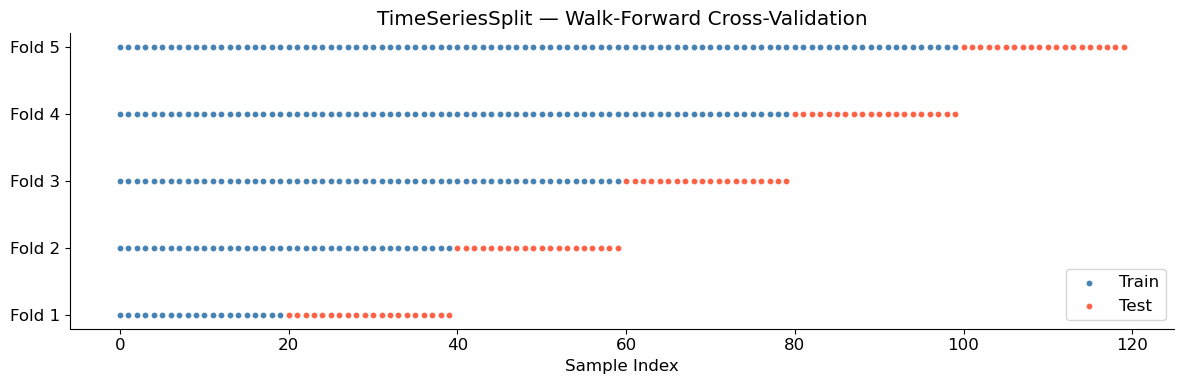

Fold R² scores:
  Fold 1: R²=-1.6945  (train=20, test=20)
  Fold 2: R²=-0.3408  (train=40, test=20)
  Fold 3: R²=-0.4632  (train=60, test=20)
  Fold 4: R²=-0.4915  (train=80, test=20)
  Fold 5: R²=0.0509  (train=100, test=20)

Mean R²: -0.5878 ± 0.5863


In [90]:
tscv = TimeSeriesSplit(n_splits=5)

fold_scores = []
fold_train_sizes = []
fold_test_sizes  = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_ts)):
    X_tr_f = scaler_ts.fit_transform(X_ts.iloc[tr_idx])
    X_te_f = scaler_ts.transform(X_ts.iloc[te_idx])

    ridge_f = Ridge(alpha=10)
    ridge_f.fit(X_tr_f, y_ts.iloc[tr_idx])
    score = r2_score(y_ts.iloc[te_idx], ridge_f.predict(X_te_f))
    fold_scores.append(score)
    fold_train_sizes.append(len(tr_idx))
    fold_test_sizes.append(len(te_idx))

# ── Visualise folds ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
colors_train = 'steelblue'
colors_test  = 'tomato'

for i, (tr_idx, te_idx) in enumerate(tscv.split(X_ts)):
    ax.scatter(tr_idx, [i] * len(tr_idx), c=colors_train, s=10, label='Train' if i==0 else '')
    ax.scatter(te_idx, [i] * len(te_idx), c=colors_test,  s=10, label='Test'  if i==0 else '')

ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel('Sample Index')
ax.set_title('TimeSeriesSplit — Walk-Forward Cross-Validation')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("Fold R² scores:")
for i, (s, tr, te) in enumerate(zip(fold_scores, fold_train_sizes, fold_test_sizes)):
    print(f"  Fold {i+1}: R²={s:.4f}  (train={tr}, test={te})")
print(f"\nMean R²: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")


---
## 20. Summary & Key Takeaways

| # | Topic | Key Insight |
|---|-------|-------------|
| 1 | Data Cleaning | 0 missing values; created `Date` column for time-series work |
| 2 | EDA | Strong upward trend; Model Y dominates; North America leads |
| 3 | Encoding | OHE for nominal cats; Label Enc for ordinal / tree models |
| 4 | Scaling | RobustScaler preferred for delivery counts (right-skewed) |
| 5 | Feature Eng | `Revenue_Proxy` & `Production_Efficiency` add predictive signal |
| 6 | Pipelines | Wrap all preprocessing + model to prevent leakage |
| 7 | Data Leakage | Scaling before split inflates metrics — always use Pipelines |
| 8–10 | Regression | Ridge α≈10 slightly outperforms plain OLS; Lasso provides sparsity |
| 11 | Metrics | MAPE useful for scale-independent comparison across regions |
| 12 | Cross-Val | 5-fold CV gives stable R² estimates |
| 13 | HP Tuning | GridSearchCV confirms best Ridge α |
| 14 | TS Decomp | Clear multiplicative seasonality + strong upward trend |
| 15 | Stationarity | Raw series non-stationary; first difference makes it stationary |
| 16 | Lag Features | Lag-1, Lag-12 most correlated with current deliveries |
| 17 | Rolling Stats | 6-month moving average balances smoothing vs responsiveness |
| 18 | Forecasting | Ridge + lag features achieves strong out-of-sample accuracy |
| 19 | Chron. Split | TimeSeriesSplit prevents future leakage in walk-forward CV |

